AI-BASED RESUME SCREENING AND CANDIDATE SHORTLISTING SYSTEM

Project Objective

The company's HR team receives a very high number of resumes for every job opening. Manual screening is slow, inconsistent, and biased, so good candidates are missed and hiring decisions are delayed. As a Data Scientist, your task is to identify the screening problem so that recruiters get real-time insights and can shortlist candidates accordingly. Previous methods relied on manual review and simple keyword search, which were outdated and inaccurate. The company now needs an AI-based system that parses resumes, matches them to job descriptions, and ranks and shortlists the best candidates automatically.

Goals and Success Metrics
The system succeeds if it cuts screening time sharply while keeping its shortlist close to what a human recruiter would choose.
Objectives

*  Parse resumes into structured data (skills, education, experience, projects)
*  Match candidates to a JD by meaning, not only keywords

*   Rank candidates with a transparent, adjustable score
*   Explain each shortlist decision

*   Check the model for bias before release








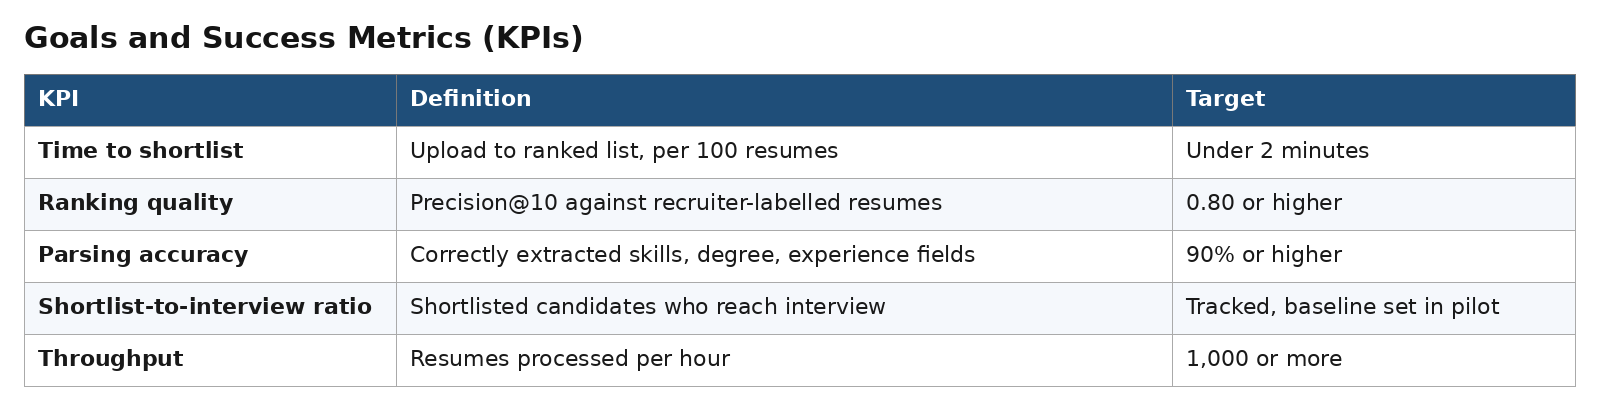

Scope

In scope

*   Bulk upload of PDF and DOCX resumes
*   Resume parsing and skill extraction

*   Explanation and skill-gap view per candidate
*   Model evaluation and bias check

Out of scope

*   Automated rejection emails or interview scheduling
*   Integration with a live applicant tracking system (ATS)







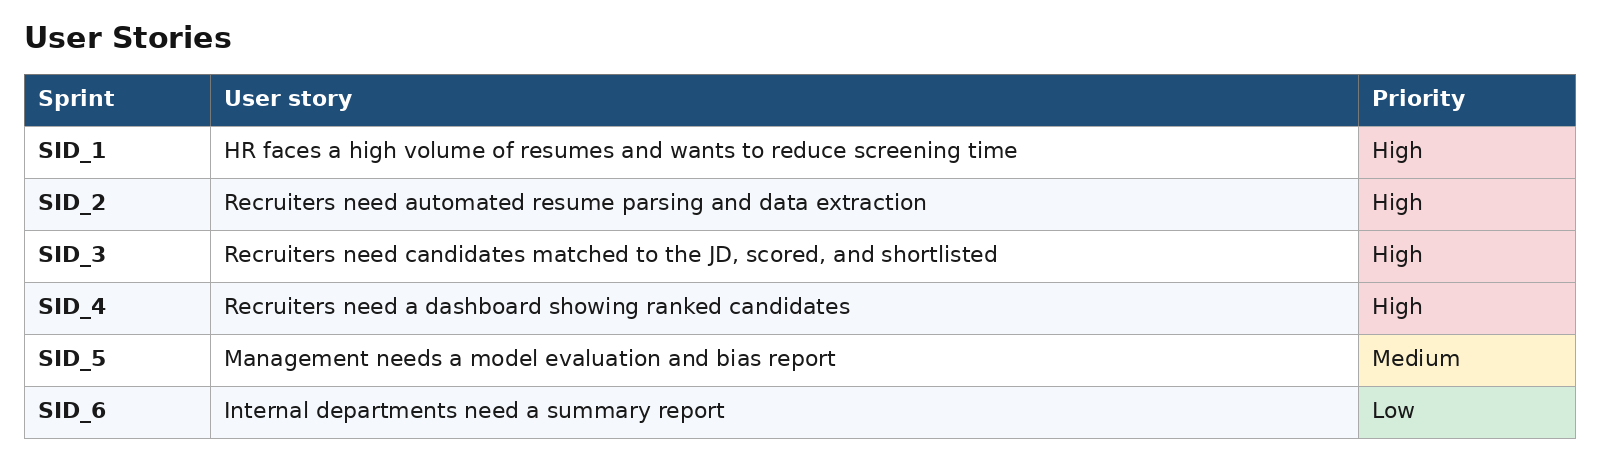

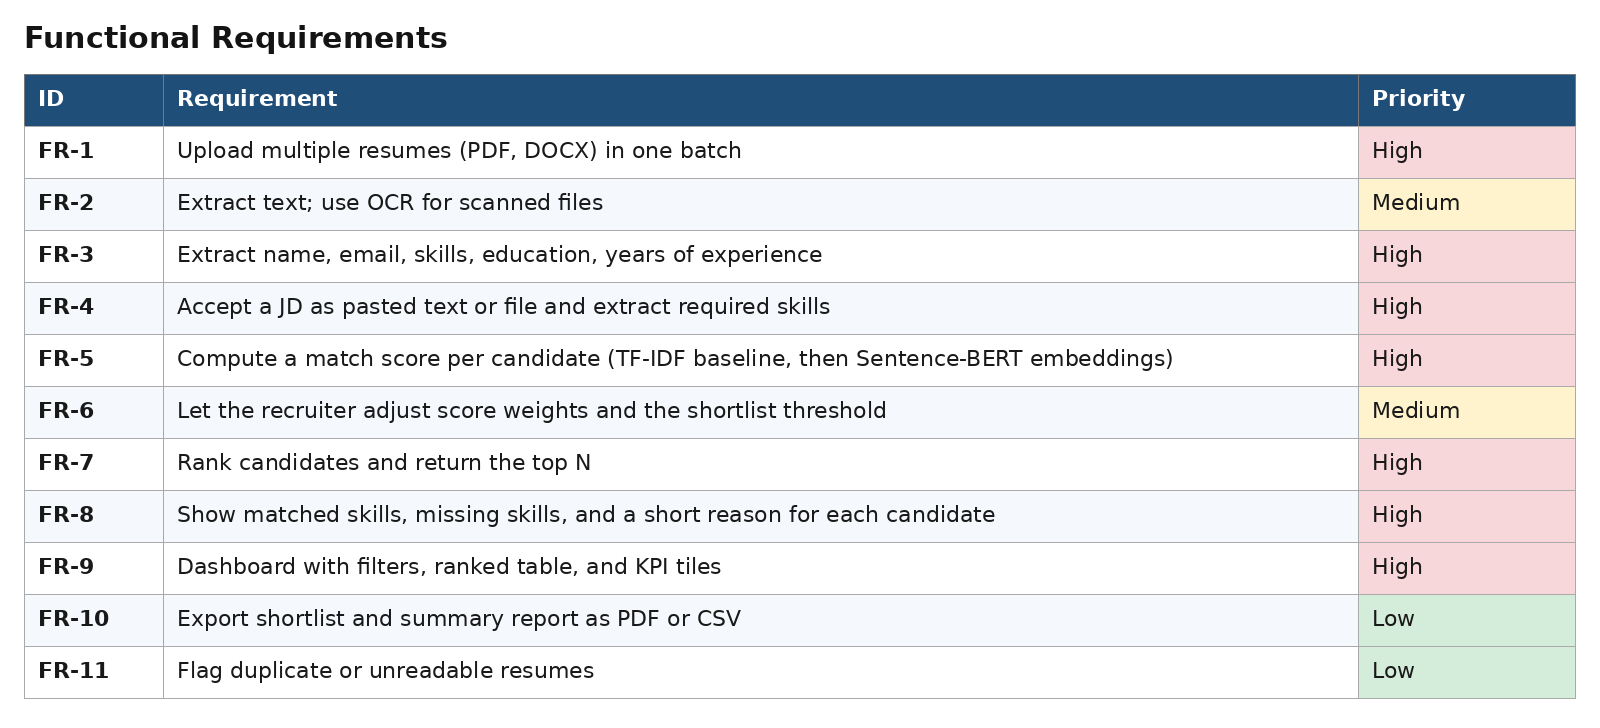

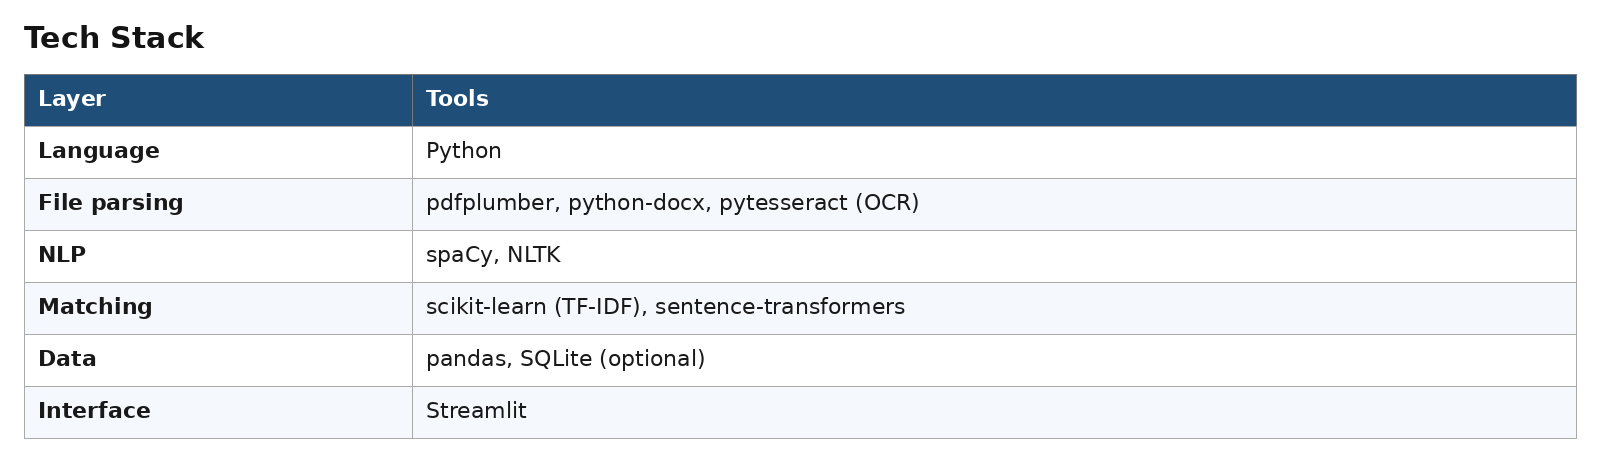

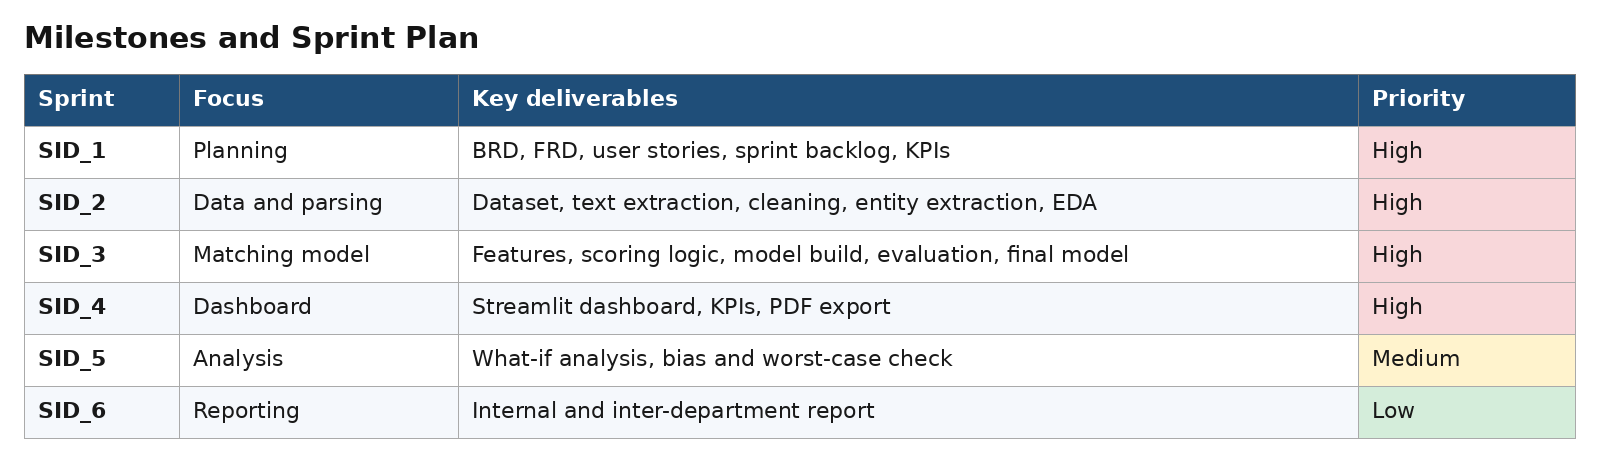

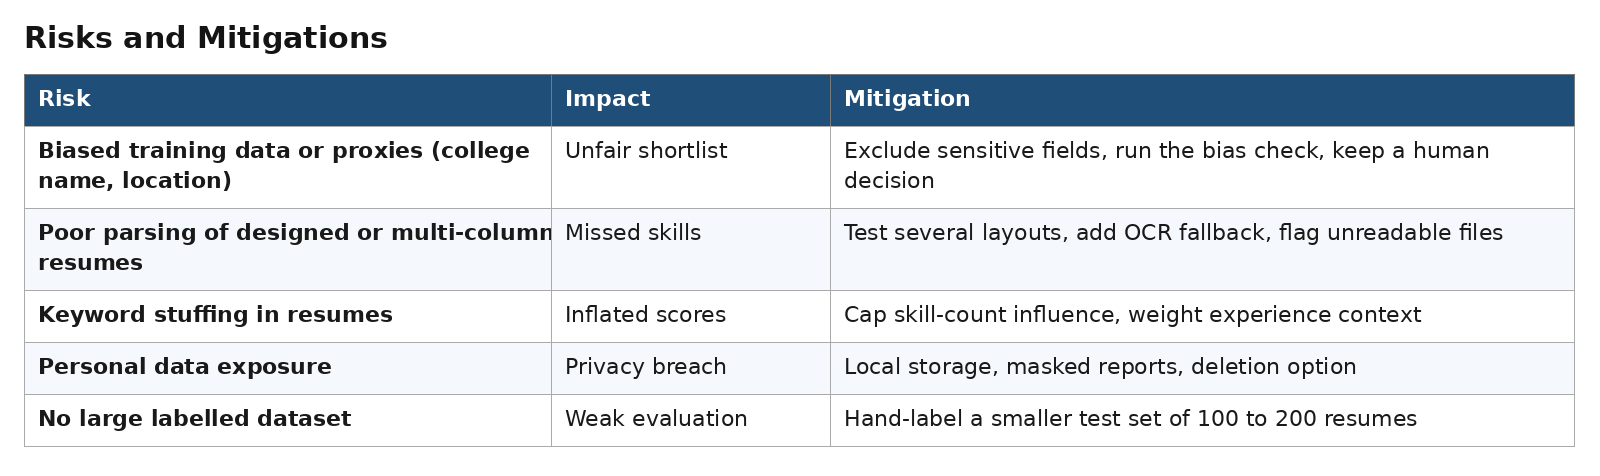

In [1]:
#upload dataset
from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()

filename = next(iter(uploaded))

df = pd.read_csv("/content/resume dataset use.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Saving resume dataset use.csv to resume dataset use (1).csv
Dataset loaded successfully!
Rows: 9544
Columns: 35


In [2]:
#View Dataset
df.head()

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,online_links,issue_dates,expiry_dates,﻿job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.850000
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.750000
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,NaN,NaN,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667
3,NaN,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name...",...,NaN,NaN,NaN,Business Development Executive,Bachelor/Honors,1 to 3 years,Age 22 to 30 years,Apparel Sourcing\nQuality Garment Sourcing\nRe...,Fast typing skill\nIELTSInternet browsing & on...,0.760000
4,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,[None],[None],"['February 15, 2021']",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,NaN,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.650000


In [3]:
#check column
print(df.columns.tolist())

['address', 'career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'educational_results', 'result_types', 'major_field_of_studies', 'professional_company_names', 'company_urls', 'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'locations', 'responsibilities', 'extra_curricular_activity_types', 'extra_curricular_organization_names', 'extra_curricular_organization_links', 'role_positions', 'languages', 'proficiency_levels', 'certification_providers', 'certification_skills', 'online_links', 'issue_dates', 'expiry_dates', '\ufeffjob_position_name', 'educationaL_requirements', 'experiencere_requirement', 'age_requirement', 'responsibilities.1', 'skills_required', 'matched_score']


In [4]:
#clean column name
df.columns = (
    df.columns
    .str.replace("\ufeff", "", regex=False)
    .str.strip()
)

print(df.columns.tolist())


['address', 'career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'educational_results', 'result_types', 'major_field_of_studies', 'professional_company_names', 'company_urls', 'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'locations', 'responsibilities', 'extra_curricular_activity_types', 'extra_curricular_organization_names', 'extra_curricular_organization_links', 'role_positions', 'languages', 'proficiency_levels', 'certification_providers', 'certification_skills', 'online_links', 'issue_dates', 'expiry_dates', 'job_position_name', 'educationaL_requirements', 'experiencere_requirement', 'age_requirement', 'responsibilities.1', 'skills_required', 'matched_score']


In [5]:
#check dataset information
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (9544, 35)

Missing Values:
address                                8760
career_objective                       4804
skills                                   56
educational_institution_name             84
degree_names                             84
passing_years                            84
educational_results                      84
result_types                             84
major_field_of_studies                   84
professional_company_names               84
company_urls                             84
start_dates                              84
end_dates                                84
related_skils_in_job                     84
positions                                84
locations                                84
responsibilities                          0
extra_curricular_activity_types        6118
extra_curricular_organization_names    6118
extra_curricular_organization_links    6118
role_positions                         6118
languages                        

In [6]:
#create resume text
resume_columns = [
    "career_objective",
    "skills",
    "degree_names",
    "major_field_of_studies",
    "positions",
    "responsibilities"
]

for col in resume_columns:
    if col not in df.columns:
        df[col] = ""

df["resume_text"] = (
    df["career_objective"].fillna("").astype(str) + " " +
    df["skills"].fillna("").astype(str) + " " +
    df["degree_names"].fillna("").astype(str) + " " +
    df["major_field_of_studies"].fillna("").astype(str) + " " +
    df["positions"].fillna("").astype(str) + " " +
    df["responsibilities"].fillna("").astype(str)
)

print(df["resume_text"].iloc[0])

Big data analytics working and database warehouse manager with robust experience in handling all kinds of data. I have also used multiple cloud infrastructure services and am well acquainted with them. Currently in search of role that offers more of development. ['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapreduce', 'Spark', 'Java', 'Machine Learning', 'Cloud', 'Hdfs', 'YARN', 'Core Java', 'Data Science', 'C++', 'Data Structures', 'DBMS', 'RDBMS', 'Informatica', 'Talend', 'Amazon Redshift', 'Microsoft Azure'] ['B.Tech'] ['Electronics'] ['Big Data Analyst'] Technical Support
Troubleshooting
Collaboration
Documentation
System Monitoring
Software Deployment
Training & Mentorship
Industry Trends
Field Visits







In [7]:
#create job description text
job_columns = [
    "job_position_name",
    "educationaL_requirements",
    "experiencere_requirement",
    "responsibilities.1",
    "skills_required"
]

for col in job_columns:
    if col not in df.columns:
        df[col] = ""

df["job_text"] = (
    df["job_position_name"].fillna("").astype(str) + " " +
    df["educationaL_requirements"].fillna("").astype(str) + " " +
    df["experiencere_requirement"].fillna("").astype(str) + " " +
    df["responsibilities.1"].fillna("").astype(str) + " " +
    df["skills_required"].fillna("").astype(str)
)

print(df["job_text"].iloc[0])

Senior Software Engineer B.Sc in Computer Science & Engineering from a reputed university. At least 1 year Technical Support
Troubleshooting
Collaboration
Documentation
System Monitoring
Software Deployment
Training & Mentorship
Industry Trends
Field Visits




 


In [8]:
#clean text
import re

def clean_text(text):
    text = str(text).lower()

    text = re.sub(
        r"[^a-zA-Z0-9\s+#.]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()

df["resume_clean"] = df["resume_text"].apply(clean_text)
df["job_clean"] = df["job_text"].apply(clean_text)

print("Text cleaning completed!")

Text cleaning completed!


In [9]:
#view clean text
print("RESUME:")
print(df["resume_clean"].iloc[0])

print("\n" + "="*80 + "\n")

print("JOB DESCRIPTION:")
print(df["job_clean"].iloc[0])


RESUME:
big data analytics working and database warehouse manager with robust experience in handling all kinds of data. i have also used multiple cloud infrastructure services and am well acquainted with them. currently in search of role that offers more of development. big data hadoop hive python mapreduce spark java machine learning cloud hdfs yarn core java data science c++ data structures dbms rdbms informatica talend amazon redshift microsoft azure b.tech electronics big data analyst technical support troubleshooting collaboration documentation system monitoring software deployment training mentorship industry trends field visits


JOB DESCRIPTION:
senior software engineer b.sc in computer science engineering from a reputed university. at least 1 year technical support troubleshooting collaboration documentation system monitoring software deployment training mentorship industry trends field visits


In [10]:
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

all_text = pd.concat([
    df["resume_clean"],
    df["job_clean"]
])

vectorizer.fit(all_text)

resume_vectors = vectorizer.transform(
    df["resume_clean"]
)

job_vectors = vectorizer.transform(
    df["job_clean"]
)

print("Resume vectors:", resume_vectors.shape)
print("Job vectors:", job_vectors.shape)


Resume vectors: (9544, 3355)
Job vectors: (9544, 3355)


In [11]:
#cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity_scores = []

for i in range(len(df)):

    score = cosine_similarity(
        resume_vectors[i],
        job_vectors[i]
    )[0][0]

    similarity_scores.append(score)

df["similarity_score"] = similarity_scores

print(df["similarity_score"].describe())


count    9544.000000
mean        0.379284
std         0.149545
min         0.063396
25%         0.266233
50%         0.356306
75%         0.471811
max         0.869695
Name: similarity_score, dtype: float64


In [ ]:
#check similarity
df[
    [
        "job_position_name",
        "similarity_score"
    ]
].head(10)

: 

In [13]:
#define skills
skills_list = [
    "python",
    "java",
    "c",
    "c++",
    "c#",
    "sql",
    "mysql",
    "mongodb",
    "javascript",
    "react",
    "angular",
    "node.js",
    "html",
    "css",
    "machine learning",
    "deep learning",
    "data science",
    "nlp",
    "tensorflow",
    "pytorch",
    "aws",
    "azure",
    "docker",
    "kubernetes",
    "git",
    "github",
    "spring boot",
    "data structures",
    "algorithms",
    "dbms"
]

print("Number of skills:", len(skills_list))

Number of skills: 30


In [14]:
#skill extraction function
def extract_skills(text):

    text = str(text).lower()

    found = []

    for skill in skills_list:

        if skill in text:
            found.append(skill)

    return found

In [15]:
#extract candidate skill
df["detected_skills"] = (
    df["resume_clean"]
    .apply(extract_skills)
)

df[
    [
        "job_position_name",
        "detected_skills"
    ]
].head(10)

,job_position_name,detected_skills
0,Senior Software Engineer,"[python, java, c, c++, machine learning, data ..."
1,Machine Learning (ML) Engineer,"[c, machine learning, nlp]"
2,"Executive/ Senior Executive- Trade Marketing, ...","[python, java, c, c++, javascript, html, css, ..."
3,Business Development Executive,[c]
4,Senior iOS Engineer,[c]
5,AI Engineer,"[c, machine learning]"
6,Senior iOS Engineer,"[c, machine learning]"
7,Senior iOS Engineer,[c]
8,Mechanical Engineer,"[python, c, sql, mysql, machine learning, deep..."
9,Business Development Executive,"[python, c, sql, machine learning, docker, git..."


In [16]:
#extract required skill
df["required_skills"] = (
    df["job_clean"]
    .apply(extract_skills)
)

df[
    [
        "required_skills"
    ]
].head(10)

,required_skills
0,[c]
1,"[c, machine learning, nlp]"
2,[c]
3,[c]
4,[c]
5,"[python, java, c, machine learning, tensorflow..."
6,[c]
7,[c]
8,[c]
9,[c]


In [17]:
#calculate skill matching
def skill_match(row):

    required = set(
        row["required_skills"]
    )

    candidate = set(
        row["detected_skills"]
    )

    if len(required) == 0:
        return 0

    matched = required.intersection(
        candidate
    )

    return len(matched) / len(required)


df["skill_match"] = df.apply(
    skill_match,
    axis=1
)

print(df["skill_match"].describe())

count    9544.000000
mean        0.903456
std         0.222114
min         0.166667
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: skill_match, dtype: float64


In [18]:
#count match skill
df["matched_skill_count"] = df.apply(
    lambda row: len(
        set(row["detected_skills"])
        .intersection(
            set(row["required_skills"])
        )
    ),
    axis=1
)

df[
    [
        "detected_skills",
        "required_skills",
        "matched_skill_count"
    ]
].head(10)

,detected_skills,required_skills,matched_skill_count
0,"[python, java, c, c++, machine learning, data ...",[c],1
1,"[c, machine learning, nlp]","[c, machine learning, nlp]",3
2,"[python, java, c, c++, javascript, html, css, ...",[c],1
3,[c],[c],1
4,[c],[c],1
5,"[c, machine learning]","[python, java, c, machine learning, tensorflow...",2
6,"[c, machine learning]",[c],1
7,[c],[c],1
8,"[python, c, sql, mysql, machine learning, deep...",[c],1
9,"[python, c, sql, machine learning, docker, git...",[c],1


In [19]:
#skills coverage
df["required_skill_count"] = (
    df["required_skills"].apply(len)
)

df["candidate_skill_count"] = (
    df["detected_skills"].apply(len)
)

df["skill_coverage"] = df.apply(
    lambda row:
    row["matched_skill_count"] /
    row["required_skill_count"]
    if row["required_skill_count"] > 0
    else 0,
    axis=1
)

print(df["skill_coverage"].describe())

count    9544.000000
mean        0.903456
std         0.222114
min         0.166667
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: skill_coverage, dtype: float64


In [20]:
#word overlap
def calculate_word_overlap(resume, job):

    resume_words = set(
        resume.split()
    )

    job_words = set(
        job.split()
    )

    if len(job_words) == 0:
        return 0

    common_words = resume_words.intersection(
        job_words
    )

    return len(common_words) / len(job_words)


df["word_overlap"] = df.apply(
    lambda row: calculate_word_overlap(
        row["resume_clean"],
        row["job_clean"]
    ),
    axis=1
)

print(df["word_overlap"].describe())

count    9544.000000
mean        0.604946
std         0.108437
min         0.300000
25%         0.533333
50%         0.600000
75%         0.673077
max         0.900000
Name: word_overlap, dtype: float64


In [21]:
#resume and job length feauthr
df["resume_length"] = (
    df["resume_clean"].str.len()
)

df["job_length"] = (
    df["job_clean"].str.len()
)

df["resume_word_count"] = (
    df["resume_clean"]
    .str.split()
    .str.len()
)

df["job_word_count"] = (
    df["job_clean"]
    .str.split()
    .str.len()
)

print(
    df[
        [
            "resume_length",
            "job_length",
            "resume_word_count",
            "job_word_count"
        ]
    ].head()
)

   resume_length  job_length  resume_word_count  job_word_count
0            634         253                 89              31
1            731         529                 93              70
2            371         356                 45              44
3            860         207                102              27
4           1064         479                129              65


In [22]:
#check target
print(df["matched_score"].describe())




count    9544.000000
mean        0.660831
std         0.167040
min         0.000000
25%         0.583333
50%         0.683333
75%         0.793333
max         0.970000
Name: matched_score, dtype: float64


In [23]:
print(
    "Missing matched_score:",
    df["matched_score"].isnull().sum()
)

Missing matched_score: 0


In [24]:
#remove missing target
df = df.dropna(
    subset=["matched_score"]
).copy()

print("Rows after cleaning:", len(df))

Rows after cleaning: 9544


In [25]:
#correlation analysis
correlation_columns = [
    "matched_score",
    "similarity_score",
    "skill_match",
    "skill_coverage",
    "word_overlap",
    "candidate_skill_count",
    "required_skill_count",
    "matched_skill_count",
    "resume_length",
    "job_length",
    "resume_word_count",
    "job_word_count"
]

correlation_matrix = df[
    correlation_columns
].corr()

print(
    correlation_matrix["matched_score"]
    .sort_values(
        ascending=False
    )
)

matched_score            1.000000
word_overlap             0.373200
job_word_count           0.300864
job_length               0.290637
resume_length            0.238444
resume_word_count        0.220991
required_skill_count     0.192866
matched_skill_count      0.165523
similarity_score         0.152641
candidate_skill_count   -0.044348
skill_coverage          -0.100993
skill_match             -0.100993
Name: matched_score, dtype: float64


In [26]:
#create ml model feature
features = [
    "similarity_score",
    "skill_match",
    "skill_coverage",
    "word_overlap",
    "candidate_skill_count",
    "required_skill_count",
    "matched_skill_count",
    "resume_length",
    "job_length",
    "resume_word_count",
    "job_word_count"
]

X = df[features].copy()

y = df["matched_score"].copy()

print("Features:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['similarity_score', 'skill_match', 'skill_coverage', 'word_overlap', 'candidate_skill_count', 'required_skill_count', 'matched_skill_count', 'resume_length', 'job_length', 'resume_word_count', 'job_word_count']

X shape: (9544, 11)
y shape: (9544,)


In [27]:
#handle missing
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(0)

y = y.replace(
    [np.inf, -np.inf],
    np.nan
)

y = y.fillna(
    y.mean()
)

print("Missing X values:", X.isnull().sum().sum())
print("Missing y values:", y.isnull().sum())

Missing X values: 0
Missing y values: 0


In [28]:
#train /test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (7635, 11)
Testing data : (1909, 11)


In [29]:
#linear regression
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_pred = linear_model.predict(
    X_test
)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [30]:
#random forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

print("Random Forest trained successfully!")


Random Forest trained successfully!


In [31]:
#extra tress
from sklearn.ensemble import ExtraTreesRegressor

extra_model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

extra_model.fit(
    X_train,
    y_train
)

extra_pred = extra_model.predict(
    X_test
)

print("Extra Trees trained successfully!")

Extra Trees trained successfully!


In [32]:
#gradient boosting
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

gb_pred = gb_model.predict(
    X_test
)

print("Gradient Boosting trained successfully!")

Gradient Boosting trained successfully!


In [34]:
#evalute model
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(
    name,
    actual,
    predicted
):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    return [
        name,
        mae,
        rmse,
        r2
    ]

In [35]:
#create model comparsion
results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "Extra Trees",
        y_test,
        extra_pred
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gb_pred
    )
)

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
)

results_df

,Model,MAE,RMSE,R2
1,Random Forest,0.090128,0.118185,0.494902
2,Extra Trees,0.090718,0.119822,0.480810
3,Gradient Boosting,0.096719,0.123785,0.445898
0,Linear Regression,0.119627,0.149629,0.190373


In [36]:
#select best model
best_model_name = results_df.iloc[0]["Model"]

print(
    "Best model based on R²:",
    best_model_name
)

Best model based on R²: Random Forest


In [37]:
#selct prediction
if best_model_name == "Linear Regression":

    best_model = linear_model
    best_pred = linear_pred

elif best_model_name == "Random Forest":

    best_model = rf_model
    best_pred = rf_pred

elif best_model_name == "Extra Trees":

    best_model = extra_model
    best_pred = extra_pred

elif best_model_name == "Gradient Boosting":

    best_model = gb_model
    best_pred = gb_pred

print(
    "Selected model:",
    best_model_name
)

Selected model: Random Forest


In [38]:
#final evalution
final_mae = mean_absolute_error(
    y_test,
    best_pred
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_pred
    )
)

final_r2 = r2_score(
    y_test,
    best_pred
)

print("FINAL MODEL EVALUATION")
print("==============================")
print("Model :", best_model_name)
print("MAE   :", final_mae)
print("RMSE  :", final_rmse)
print("R²    :", final_r2)

FINAL MODEL EVALUATION
Model : Random Forest
MAE   : 0.09012754971317859
RMSE  : 0.11818493667321271
R²    : 0.4949018421745428


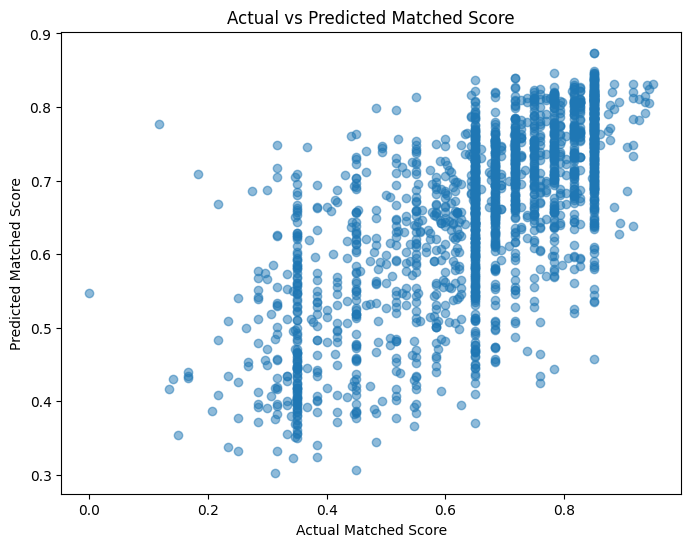

In [39]:
#actual vs prediction
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_pred,
    alpha=0.5
)

plt.xlabel(
    "Actual Matched Score"
)

plt.ylabel(
    "Predicted Matched Score"
)

plt.title(
    "Actual vs Predicted Matched Score"
)

plt.show()

In [40]:
#prediction comparsion
comparison = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": best_pred
})

comparison.head(20)

,Actual Score,Predicted Score
0,0.650000,0.667523
1,0.633333,0.641166
2,0.650000,0.369792
3,0.573333,0.714393
4,0.850000,0.785025
5,0.316667,0.530204
6,0.350000,0.522116
7,0.850000,0.702590
8,0.876667,0.802673
9,0.783333,0.605837


In [41]:
#feature importance
if best_model_name == "Random Forest":

    importance_values = (
        rf_model.feature_importances_
    )

elif best_model_name == "Extra Trees":

    importance_values = (
        extra_model.feature_importances_
    )

elif best_model_name == "Gradient Boosting":

    importance_values = (
        gb_model.feature_importances_
    )

else:

    importance_values = None

In [42]:
#display feature importance
if importance_values is not None:

    importance_df = pd.DataFrame({
        "Feature": features,
        "Importance": importance_values
    })

    importance_df = importance_df.sort_values(
        "Importance",
        ascending=False
    )

    print(importance_df)

else:

    print(
        "Linear Regression selected. "
        "Feature importance is represented by coefficients."
    )

                  Feature  Importance
3            word_overlap    0.229763
0        similarity_score    0.162759
10         job_word_count    0.154065
7           resume_length    0.122843
4   candidate_skill_count    0.099991
9       resume_word_count    0.096653
8              job_length    0.088665
5    required_skill_count    0.022443
2          skill_coverage    0.008156
1             skill_match    0.008121
6     matched_skill_count    0.006542


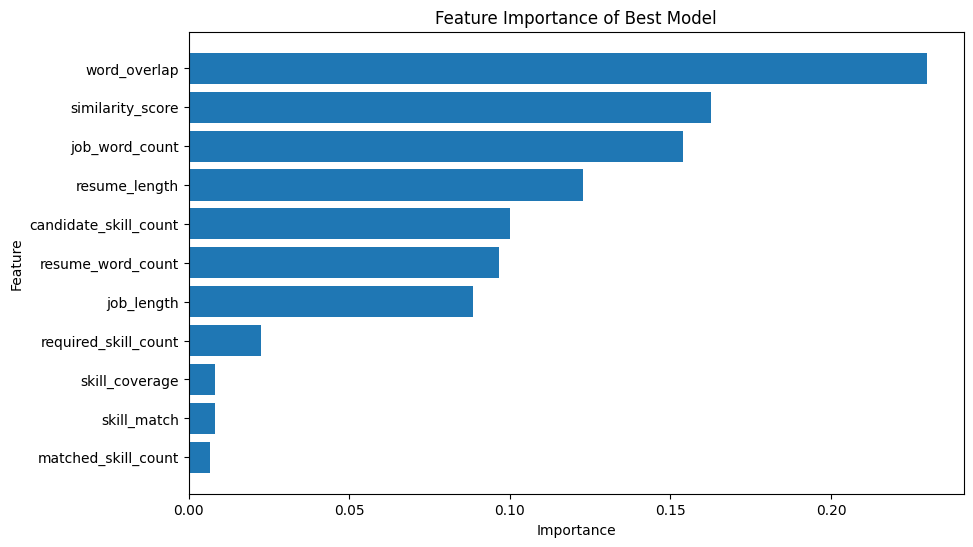

In [43]:
#feature importance graph
if importance_values is not None:

    plt.figure(figsize=(10, 6))

    plt.barh(
        importance_df["Feature"],
        importance_df["Importance"]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.title(
        "Feature Importance of Best Model"
    )

    plt.gca().invert_yaxis()

    plt.show()

In [44]:
#linear regression coefficient
linear_coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": linear_model.coef_
})

linear_coefficients = (
    linear_coefficients
    .sort_values(
        "Coefficient",
        ascending=False
    )
)

linear_coefficients

,Feature,Coefficient
3,word_overlap,0.352501
0,similarity_score,0.097262
1,skill_match,0.052111
2,skill_coverage,0.052111
5,required_skill_count,0.031920
7,resume_length,0.000198
8,job_length,0.000161
10,job_word_count,0.000049
9,resume_word_count,-0.001052
4,candidate_skill_count,-0.004876


In [45]:
#cross validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation R² Scores:")
print(cv_scores)

print(
    "\nAverage CV R²:",
    cv_scores.mean()
)

print(
    "Standard Deviation:",
    cv_scores.std()
)

Cross Validation R² Scores:
[0.46870174 0.47649195 0.47809661 0.44854317 0.467432  ]

Average CV R²: 0.46785309283509297
Standard Deviation: 0.010519793121223664


In [46]:
#save final model
import joblib

joblib.dump(
    best_model,
    "resume_matching_model.pkl"
)

joblib.dump(
    vectorizer,
    "tfidf_vectorizer.pkl"
)

joblib.dump(
    features,
    "model_features.pkl"
)

print("All model files saved successfully!")

All model files saved successfully!


In [52]:
#download model
from google.colab import files

files.download(
    "resume_matching_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
files.download(
    "tfidf_vectorizer.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
files.download(
    "model_features.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
#frontend
import os

required_files = [
    "resume_matching_model.pkl",
    "tfidf_vectorizer.pkl",
    "model_features.pkl"
]

for file in required_files:
    print(file, ":", "FOUND" if os.path.exists(file) else "NOT FOUND")


resume_matching_model.pkl : FOUND
tfidf_vectorizer.pkl : FOUND
model_features.pkl : FOUND


In [72]:
!pip install -q streamlit pypdf scikit-learn joblib pandas numpy

In [73]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import re
import joblib

from pypdf import PdfReader
from sklearn.metrics.pairwise import cosine_similarity


# =========================================================
# PAGE CONFIGURATION
# =========================================================

st.set_page_config(
    page_title="AI Resume Screening System",
    page_icon="🤖",
    layout="wide"
)


# =========================================================
# LOAD TRAINED FILES
# =========================================================

try:

    model = joblib.load(
        "resume_matching_model.pkl"
    )

    vectorizer = joblib.load(
        "tfidf_vectorizer.pkl"
    )

    features = joblib.load(
        "model_features.pkl"
    )

except Exception as e:

    st.error("Unable to load trained model files.")

    st.exception(e)

    st.stop()


# =========================================================
# CUSTOM CSS
# =========================================================

st.markdown(
    """
    <style>

    .main-title {
        font-size: 42px;
        font-weight: 700;
        text-align: center;
        margin-bottom: 5px;
    }

    .sub-title {
        text-align: center;
        font-size: 18px;
        margin-bottom: 30px;
    }

    .result-box {
        padding: 20px;
        border-radius: 12px;
        border: 1px solid #ddd;
        text-align: center;
    }

    </style>
    """,
    unsafe_allow_html=True
)


# =========================================================
# FUNCTIONS
# =========================================================

def extract_pdf_text(uploaded_file):

    reader = PdfReader(uploaded_file)

    text = ""

    for page in reader.pages:

        page_text = page.extract_text()

        if page_text:

            text += page_text + " "

    return text


def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r"[^a-zA-Z0-9\s+#.]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


# =========================================================
# SKILL LIST
# =========================================================

skills_list = [

    "python",
    "java",
    "c",
    "c++",
    "c#",

    "sql",
    "mysql",
    "mongodb",

    "javascript",
    "react",
    "angular",
    "node.js",

    "html",
    "css",

    "machine learning",
    "deep learning",
    "data science",
    "nlp",

    "tensorflow",
    "pytorch",

    "aws",
    "azure",

    "docker",
    "kubernetes",

    "git",
    "github",

    "spring boot",

    "data structures",
    "algorithms",
    "dbms"
]


def extract_skills(text):

    text = str(text).lower()

    found = []

    for skill in skills_list:

        if skill in text:

            found.append(skill)

    return found


def word_overlap(resume, job):

    resume_words = set(
        resume.split()
    )

    job_words = set(
        job.split()
    )

    if len(job_words) == 0:

        return 0

    common_words = (
        resume_words.intersection(
            job_words
        )
    )

    return (
        len(common_words)
        /
        len(job_words)
    )


# =========================================================
# HEADER
# =========================================================

st.markdown(
    '<div class="main-title">'
    '🤖 AI Resume Screening System'
    '</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="sub-title">'
    'AI-Based Resume Screening and Candidate Shortlisting System'
    '</div>',
    unsafe_allow_html=True
)

st.divider()


# =========================================================
# SIDEBAR
# =========================================================

with st.sidebar:

    st.header("📌 Project")

    st.write(
        """
        **P_204**

        AI-Based Resume Screening and
        Candidate Shortlisting System
        """
    )

    st.divider()

    st.subheader("Technology")

    st.write(
        """
        • Python

        • Machine Learning

        • TF-IDF

        • Cosine Similarity

        • Streamlit

        • PDF Processing
        """
    )

    st.divider()

    st.info(
        "The system provides screening assistance. "
        "Final hiring decisions should remain with a human reviewer."
    )


# =========================================================
# INPUT SECTION
# =========================================================

st.header("📄 Resume Screening")

col1, col2 = st.columns(2)


# =========================================================
# RESUME UPLOAD
# =========================================================

with col1:

    st.subheader("Resume")

    uploaded_resume = st.file_uploader(
        "Upload Resume PDF",
        type=["pdf"]
    )


# =========================================================
# JOB DESCRIPTION
# =========================================================

with col2:

    st.subheader("Job Description")

    job_description = st.text_area(
        "Enter Job Description",
        height=250,
        placeholder=
        """
Example:

We are looking for a Python Developer
with SQL, Machine Learning, Git and
Data Structures knowledge.
        """
    )


st.write("")


# =========================================================
# ANALYZE BUTTON
# =========================================================

analyze = st.button(
    "🔍 Analyze Resume",
    type="primary",
    use_container_width=True
)


# =========================================================
# MAIN ANALYSIS
# =========================================================

if analyze:

    # -----------------------------------------------------
    # VALIDATION
    # -----------------------------------------------------

    if uploaded_resume is None:

        st.error(
            "Please upload a resume PDF."
        )

        st.stop()


    if not job_description.strip():

        st.error(
            "Please enter a job description."
        )

        st.stop()


    # -----------------------------------------------------
    # ANALYSIS
    # -----------------------------------------------------

    with st.spinner(
        "🤖 Analyzing resume..."
    ):

        try:

            # =============================================
            # EXTRACT PDF TEXT
            # =============================================

            resume_text = extract_pdf_text(
                uploaded_resume
            )


            if not resume_text.strip():

                st.error(
                    "No readable text was found "
                    "inside the PDF."
                )

                st.stop()


            # =============================================
            # CLEAN TEXT
            # =============================================

            resume_clean = clean_text(
                resume_text
            )

            job_clean = clean_text(
                job_description
            )


            # =============================================
            # TF-IDF
            # =============================================

            resume_vector = vectorizer.transform(
                [resume_clean]
            )

            job_vector = vectorizer.transform(
                [job_clean]
            )


            # =============================================
            # COSINE SIMILARITY
            # =============================================

            similarity_score = cosine_similarity(
                resume_vector,
                job_vector
            )[0][0]


            # =============================================
            # SKILL EXTRACTION
            # =============================================

            detected_skills = extract_skills(
                resume_clean
            )

            required_skills = extract_skills(
                job_clean
            )


            # =============================================
            # SET OPERATIONS
            # =============================================

            detected_set = set(
                detected_skills
            )

            required_set = set(
                required_skills
            )


            matched_skills = sorted(
                detected_set.intersection(
                    required_set
                )
            )

            missing_skills = sorted(
                required_set.difference(
                    detected_set
                )
            )


            # =============================================
            # SKILL MATCH
            # =============================================

            if len(required_skills) > 0:

                skill_match = (
                    len(matched_skills)
                    /
                    len(required_skills)
                )

            else:

                skill_match = 0


            # =============================================
            # FEATURE ENGINEERING
            # =============================================

            matched_skill_count = len(
                matched_skills
            )

            candidate_skill_count = len(
                detected_skills
            )

            required_skill_count = len(
                required_skills
            )

            skill_coverage = skill_match

            overlap = word_overlap(
                resume_clean,
                job_clean
            )

            resume_length = len(
                resume_clean
            )

            job_length = len(
                job_clean
            )

            resume_word_count = len(
                resume_clean.split()
            )

            job_word_count = len(
                job_clean.split()
            )


            # =============================================
            # MODEL INPUT
            # =============================================

            input_data = pd.DataFrame({

                "similarity_score":
                [similarity_score],

                "skill_match":
                [skill_match],

                "skill_coverage":
                [skill_coverage],

                "word_overlap":
                [overlap],

                "candidate_skill_count":
                [candidate_skill_count],

                "required_skill_count":
                [required_skill_count],

                "matched_skill_count":
                [matched_skill_count],

                "resume_length":
                [resume_length],

                "job_length":
                [job_length],

                "resume_word_count":
                [resume_word_count],

                "job_word_count":
                [job_word_count]

            })


            # =============================================
            # SAME FEATURE ORDER AS TRAINING
            # =============================================

            input_data = input_data[
                features
            ]


            # =============================================
            # MODEL PREDICTION
            # =============================================

            prediction = model.predict(
                input_data
            )[0]


            prediction = np.clip(
                prediction,
                0,
                1
            )


            score = prediction * 100


        except Exception as e:

            st.error(
                "An error occurred during analysis."
            )

            st.exception(e)

            st.stop()


    # =====================================================
    # RESULTS
    # =====================================================

    st.success(
        "✅ Resume analysis completed!"
    )

    st.divider()


    # =====================================================
    # SCORE CARDS
    # =====================================================

    col1, col2, col3 = st.columns(3)


    with col1:

        st.metric(
            "🤖 AI Match Score",
            f"{score:.2f}%"
        )


    with col2:

        st.metric(
            "📊 Resume-Job Similarity",
            f"{similarity_score * 100:.2f}%"
        )


    with col3:

        st.metric(
            "🛠️ Skill Match",
            f"{skill_match * 100:.2f}%"
        )


    # =====================================================
    # SCORE BAR
    # =====================================================

    st.subheader(
        "📈 Overall Match"
    )

    st.progress(
        min(int(score), 100)
    )


    # =====================================================
    # SCREENING RESULT
    # =====================================================

    st.subheader(
        "📌 Screening Result"
    )


    if score >= 70:

        st.success(
            "🟢 Meets Screening Threshold"
        )

    else:

        st.warning(
            "🟡 Below Screening Threshold"
        )


    # =====================================================
    # SKILLS
    # =====================================================

    st.divider()

    col1, col2 = st.columns(2)


    # -----------------------------------------------------
    # MATCHED
    # -----------------------------------------------------

    with col1:

        st.subheader(
            "✅ Matched Skills"
        )

        if matched_skills:

            for skill in matched_skills:

                st.write(
                    "✓",
                    skill
                )

        else:

            st.write(
                "No matching skills detected."
            )


    # -----------------------------------------------------
    # MISSING
    # -----------------------------------------------------

    with col2:

        st.subheader(
            "❌ Missing Skills"
        )

        if missing_skills:

            for skill in missing_skills:

                st.write(
                    "•",
                    skill
                )

        else:

            st.write(
                "No missing required skills."
            )


    # =====================================================
    # STATISTICS
    # =====================================================

    st.divider()

    st.subheader(
        "📊 Resume Statistics"
    )


    c1, c2, c3, c4 = st.columns(4)


    with c1:

        st.metric(
            "Resume Words",
            resume_word_count
        )


    with c2:

        st.metric(
            "Required Skills",
            required_skill_count
        )


    with c3:

        st.metric(
            "Matched Skills",
            matched_skill_count
        )


    with c4:

        st.metric(
            "Candidate Skills",
            candidate_skill_count
        )


    # =====================================================
    # DETAILED FEATURES
    # =====================================================

    st.divider()

    st.subheader(
        "🔎 Detailed Analysis"
    )


    details = pd.DataFrame({

        "Feature": [

            "Resume-Job Similarity",

            "Skill Match",

            "Skill Coverage",

            "Word Overlap",

            "Candidate Skill Count",

            "Required Skill Count",

            "Matched Skill Count",

            "Resume Word Count",

            "Job Description Word Count"

        ],

        "Value": [

            f"{similarity_score * 100:.2f}%",

            f"{skill_match * 100:.2f}%",

            f"{skill_coverage * 100:.2f}%",

            f"{overlap * 100:.2f}%",

            candidate_skill_count,

            required_skill_count,

            matched_skill_count,

            resume_word_count,

            job_word_count

        ]

    })


    st.dataframe(
        details,
        use_container_width=True,
        hide_index=True
    )


    # =====================================================
    # RESUME TEXT
    # =====================================================

    st.divider()

    with st.expander(
        "📄 View Extracted Resume"
    ):

        st.text_area(
            "Resume Text",
            resume_text,
            height=300
        )


    # =====================================================
    # JOB DESCRIPTION
    # =====================================================

    with st.expander(
        "💼 View Job Description"
    ):

        st.write(
            job_description
        )

Overwriting app.py


In [74]:
import os

print(
    "app.py exists:",
    os.path.exists("app.py")
)

app.py exists: True


In [75]:
!pkill -f streamlit || true

^C


In [76]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > /content/streamlit.log 2>&1 &

In [77]:
!cat /content/streamlit.log



2026-10-01 08:33:02.724 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.185.92.236:8501



In [78]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /content/cloudflared
!chmod +x /content/cloudflared

In [79]:
!/content/cloudflared --version

cloudflared version 2026.9.3 (built 2026-09-24-16:07 UTC)


In [80]:
!pkill cloudflared || true

!nohup /content/cloudflared tunnel --url http://127.0.0.1:8501 > /content/cloudflared.log 2>&1 &

In [81]:
import time
time.sleep(10)

!cat /content/cloudflared.log

2026-10-01T08:35:32Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-10-01T08:35:32Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-10-01T08:35:36Z INF +--------------------------------------------------------------------------------------------+
2026-10-01T08:35:36Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-10-01T08:35:36Z INF |  https://springer-tucson-excited-where.trycloudflare.c